/Users/shivam/uv_venvs/da/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/shivam/uv_venvs/da/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/shivam/uv_venvs/da/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


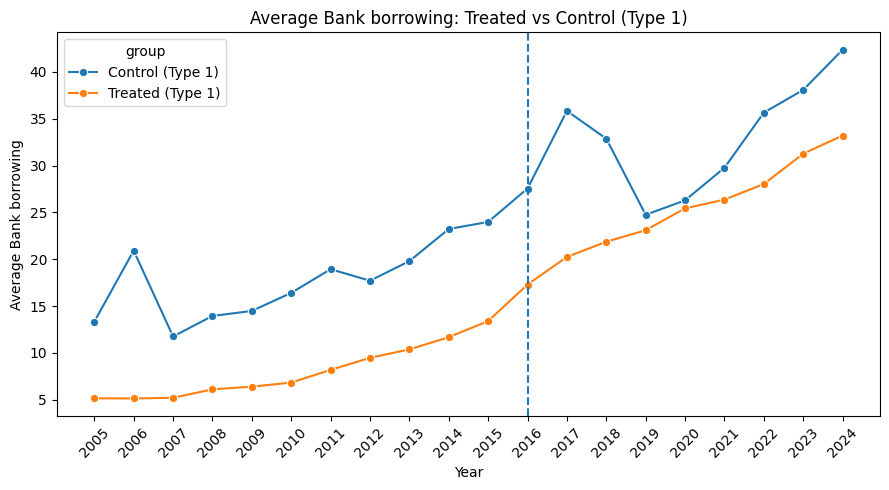

In [51]:
import pandas as pd
import numpy as np

df = pd.read_csv("renamed_master_sheet_.csv")

ID_COL = "Comp_name"

panel = (
    pd.wide_to_long(
        df,
        stubnames=["firm_size", "bank_br", "fin_br", "total_br"],
        i=ID_COL,
        j="year",
        sep="_",
        suffix=r"\d{4}"   # matches 2005, 2006, ...
    )
    .reset_index()
)

# numeric conversion
num_cols = ["firm_size", "bank_br", "fin_br", "total_br"]
panel[num_cols] = panel[num_cols].apply(pd.to_numeric, errors="coerce")

panel["year"] = panel["year"].astype(int)
panel = panel.sort_values([ID_COL, "year"]).reset_index(drop=True)

# static treatment/control based ONLY on 2015 firm size
size_2015 = (
    panel.loc[panel["year"] == 2015]
         .set_index(ID_COL)["firm_size"]
)

panel["treated_i"] = (
    panel[ID_COL].map(size_2015)
    .between(6, 10, inclusive="left")   # [7,10)
    .astype(int)
)

panel["control_i"] = (
    panel[ID_COL].map(size_2015)
    .between(10, 14, inclusive="left")  # [10,13)
    .astype(int)
)

# keep only treated + control firms
panel = panel[(panel["treated_i"] == 1) | (panel["control_i"] == 1)].copy()

# DiD time dummies
panel["post"] = (panel["year"] > 2015).astype(int)
panel["did"]  = panel["treated_i"] * panel["post"]

# outcome transform (bank borrowing is never zero)
panel["log_bank_br"] = np.log1p(panel["bank_br"])
panel["log_total_br"] = np.log(panel["total_br"])
panel["log_fin_br"] = np.log(panel["fin_br"])

# keep rows used in regressions/plots
panel = panel.dropna(subset=["bank_br", "log_bank_br"]).copy()



import seaborn as sns
import matplotlib.pyplot as plt

borrow_choice = input(
    "Choose borrowing type to plot:\n"
    "1 = Bank borrowing\n"
    "2 = Financial institution borrowing\n"
    "3 = Total borrowing\n"
    "Enter 1, 2, or 3: "
).strip()

borrow_map = {"1": "bank_br", "2": "fin_br", "3": "total_br"}
if borrow_choice not in borrow_map:
    raise ValueError("Invalid choice. Enter 1, 2, or 3.")
yvar = borrow_map[borrow_choice]

how = input("Choose aggregation type ('mean' or 'sum'): ").strip().lower()
if how not in ["mean", "sum"]:
    raise ValueError("Invalid input. Enter 'mean' or 'sum'.")

borrow_label_map = {
    "bank_br": "Bank borrowing",
    "fin_br": "Financial institution borrowing",
    "total_br": "Total borrowing",
}

plot_df = panel.copy()
plot_df["group"] = np.where(plot_df["treated_i"] == 1, "Treated (Type 1)", "Control (Type 1)")

if how == "mean":
    plot_df = plot_df.groupby(["year", "group"], as_index=False)[yvar].mean()
else:
    plot_df = plot_df.groupby(["year", "group"], as_index=False)[yvar].sum()

plt.figure(figsize=(9, 5))
sns.lineplot(data=plot_df, x="year", y=yvar, hue="group", marker="o", errorbar=None)
plt.axvline(2016, linestyle="--", linewidth=1.5)
plt.xlabel("Year")

ylabel = f"Average {borrow_label_map[yvar]}" if how == "mean" else f"Total {borrow_label_map[yvar]}"
plt.ylabel(ylabel)
plt.title(f"{ylabel}: Treated vs Control (Type 1)")
plt.xticks(sorted(plot_df["year"].unique()), rotation=45)
plt.tight_layout()
plt.show()


In [38]:


summary_by_firm = panel.groupby('treated_i')[['bank_br']].describe()
print(summary_by_firm)


           bank_br                                                            
             count       mean         std   min   25%    50%      75%      max
treated_i                                                                     
0           7980.0  26.031066  172.381264  0.01  3.21  8.755  19.7175  8569.00
1          10897.0  17.777195   54.409603  0.01  2.34  6.600  15.7400  1648.37


## DiD - TWFE

$  Y_{it} = \beta_{1} * (Treated_i) + \beta_{2} * (Treated_i) + \beta_{3} * (Treated_i × Post_t) + f_i + \lambda_t + e_{it} $  

 where, $Y_{it}$:
- Bank borrowing
- Total borrwing
- Fin instituions bororwing

In [67]:
from linearmodels.panel import PanelOLS

did_start_year = 2010
did_end_year   = 2024


df_did = panel[
    (panel["year"] >= did_start_year) &
    (panel["year"] <= did_end_year)
].copy()

df_did = df_did.set_index([ID_COL, "year"]).sort_index()

mod = PanelOLS(
    df_did["bank_br"],
    df_did[["did"]],
    entity_effects=True,
    time_effects=True
)

res = mod.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                bank_br   R-squared:                     1.873e-05
Estimator:                   PanelOLS   R-squared (Between):              0.0024
No. Observations:               16172   R-squared (Within):               0.0007
Date:                Fri, Feb 13 2026   R-squared (Overall):              0.0016
Time:                        11:55:24   Log-likelihood                 -9.31e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.2763
Entities:                        1407   P-value                           0.5992
Avg Obs:                       11.494   Distribution:                 F(1,14750)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             0.2667
                            

In [47]:
#To export the panel data for R analysis 
panel.to_csv("R_panel_data.csv", index=True)